# Task 3.1 Dynamic Circuit

이 notebook은 어떻게 dynamic circuit을 만드는지 다룹니다.

*   하나 또는 여럿의 classical register를 단순한 if-else 문장이나, 더 복잡한 표현에 적용하는 **Classical Feed forward**와 **Control Flow**
*   Qiskit runtime에서 classical control flows를 사용할때 **제약**.

In [1]:
# 필요 라이브러리 불러오기
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.circuit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.classical import expr
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit import transpile

print("라이브러리를 잘 불러왔습니다.")

라이브러리를 잘 불러왔습니다.


## Classical Feedforward와 Control Flow

"Classical feedforward(https://quantum.cloud.ibm.com/docs/en/guides/classical-feedforward-and-control-flow)"란 양자회로가 측정결과에 따라 다른 operation을 수행할수 있게 해주는 기능입니다.

- 효과적으로 양자상태 준비하기
- 효과적으로 장거리 entanglement 만들기

등에 유용합니다.

### Classical 조건을 사용한 IF 문장

`if_test` 함수는 classical register의 값에 따른 조건부 operation을 가능하게 합니다. `with`와 함께 context manager로 사용되며, `else` block도 context manager로 더할 수 있습니다.
측정기반 quantum computing, adaptive algorithms, 오차수정 algorithm 등에 쓰입니다.

Dynamic Circuit with Classical Conditional:


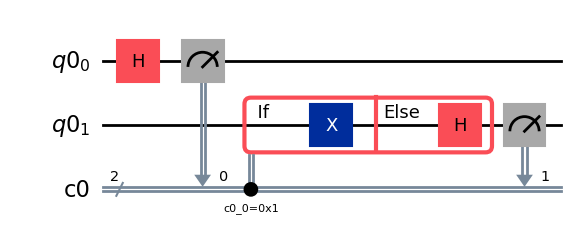


Measurement results:
{'11': 510, '00': 256, '10': 258}


In [2]:
# quantum + classical register 준비
qubits = QuantumRegister(2)
clbits = ClassicalRegister(2)
circuit = QuantumCircuit(qubits, clbits)
(q0,q1) = qubits
(c0,c1) = clbits
 
# Step 1: h-gate, 측정
circuit.h(q0)                    # Hadamard: |0⟩ → (|0⟩ + |1⟩) / √2
circuit.measure(q0, c0)          # qubit q0를 측정해서 classical bit c0에 저장
 
# Step 2: 측정결과에 따른 조건부 operation
with circuit.if_test((c0, 1)) as else_:
    circuit.x(q1)               # c0 측정결과가 1이면 X gate를 q1에 적용
with else_:
    circuit.h(q1)               # 아니면 H gate를 q1에 적용

# Step 3: q1을 측정해서 c1에 저장
circuit.measure(q1, c1)

print("Dynamic Circuit with Classical Conditional:")
display(circuit.draw("mpl"))

# 가짜 backend로 회로를 돌려서 결과 확인
backend = GenericBackendV2(num_qubits=len(circuit.qubits), control_flow=True)
transpiled_circuit = transpile(circuit, backend)
result = backend.run(transpiled_circuit).result()
print("\nMeasurement results:")
print(result.get_counts())

# - c0가 1 (=|1⟩)이면 X gate가 q1에 적용되어, c1은 1
# - c0가 0 (=|0⟩)이면 H gate가 q1에 적용되어, c1은 같은 확률로 0 또는 1

### Classical Register 여러 개를 사용하는 if 문장

여러개의 classical register를 사용해서 if 문장을 작성하면 더 복잡한 조건문을 만들수 있습니다.

Dynamic Circuit for multiple bits register


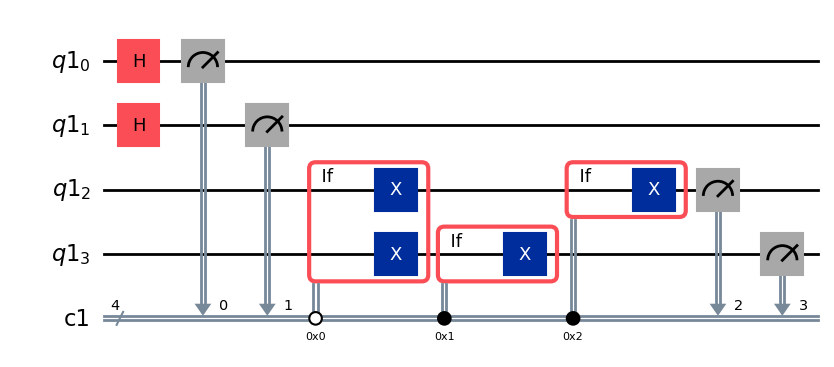


Measurement results:
{'1101': 1, '0110': 274, '0011': 266, '1100': 249, '1001': 234}


In [3]:
# quantum + classical register 준비
qubits = QuantumRegister(4)
clbits = ClassicalRegister(4)
circuit = QuantumCircuit(qubits, clbits)
(q0,q1,q2,q3) = qubits
(c0,c1,c2,c3) = clbits
 
# Step 1: h-gate, 측정
circuit.h([q0, q1])                 # Hadamard를 |00⟩에 적용 → (|00⟩ + |01⟩ + |10⟩ + |11⟩) / 2
circuit.measure([q0, q1], [c0, c1]) # q0, q1을 측정해서 c0, c1에 저장
 
# Step 2: 측정결과에 따른 조건부 operation
with circuit.if_test((clbits, 0b0000)):
    circuit.x(q2)               
    circuit.x(q3)               # c1c0 == 00면 X gate를 q2, q3에 적용
with circuit.if_test((clbits, 0b0001)):
    circuit.x(q3)               # c1c0 == 01이면 X gate를 q3에 적용
with circuit.if_test((clbits, 0b0010)):
    circuit.x(q2)               # c1c0 == 10면 X gate를 q2에 적용

# Step 3: q2, q3 측정
circuit.measure([q2,q3], [c2,c3])
 
print("Dynamic Circuit for multiple bits register")
display(circuit.draw("mpl"))

# 가짜 backend로 회로를 돌려서 결과 확인
backend = GenericBackendV2(num_qubits=len(circuit.qubits), control_flow=True)
transpiled_circuit = transpile(circuit, backend)
result = backend.run(transpiled_circuit).result()
print("\nMeasurement results:")
print(result.get_counts())
 
# - c1c0 = 00 -> X gate를 q2, q3에 적용 -> c3c2 = 11
# - c1c0 = 01 -> X gate를 q3에 적용 -> c3c2 = 10
# - c1c0 = 10 -> X gate를 q2에 적용 -> c3c2 = 01
# - c1c0 = 11 -> 아무 일도 안함 -> c3c2 = 00

### 더욱 더 복잡한 조건 만들기

Qiskit이 제공하는 `expr` module을 사용하면 여러 classical bit을 가지고 더욱 복잡하고 정교한 조건부 논리를 구성할수 있습니다.

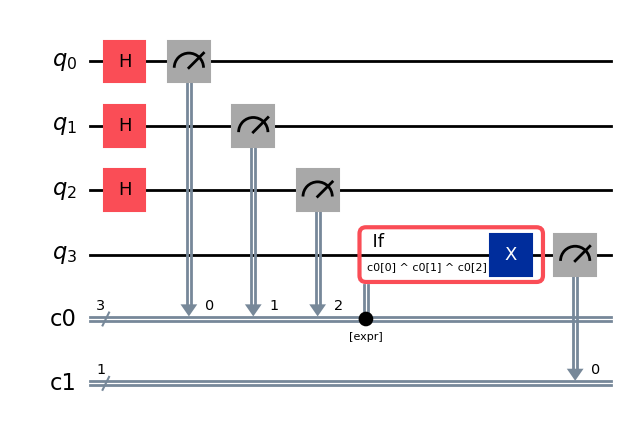


Measurement results:
{'1 010': 122, '0 101': 107, '1 001': 137, '0 011': 132, '1 111': 137, '1 000': 1, '1 100': 122, '0 110': 143, '0 010': 1, '0 000': 122}


In [5]:
# quantum + classical register 준비
qr = QuantumRegister(4, 'q')
cr0 = ClassicalRegister(3, 'c0')
cr1 = ClassicalRegister(1, 'c1')
circuit = QuantumCircuit(qr, cr0, cr1)

# Step 1: h-gate, 측정
circuit.h(qr[0])
circuit.h(qr[1])
circuit.h(qr[2])
circuit.measure(qr[0:3], cr0)

# `expr`을 사용해서 세 classical bit을 모두 XOR로 연결하는 조건(=parity check)을 만듬
_condition = expr.bit_xor(expr.bit_xor(cr0[0], cr0[1]), cr0[2])

# parity가 odd면 (XOR = 1) X gate를 q3에 적용
with circuit.if_test(_condition):
    circuit.x(qr[3])

# q3 측정
circuit.measure(qr[3], cr1)

display(circuit.draw("mpl"))

# 가짜 backend로 회로를 돌려서 결과 확인
backend = GenericBackendV2(num_qubits=len(circuit.qubits), control_flow=True)
transpiled_circuit = transpile(circuit, backend)
result = backend.run(transpiled_circuit).result()
print("\nMeasurement results:")
print(result.get_counts())

# parity odd, 즉 q0, q1, q2 중 홀수개의 qubit이 1이면 q3 = 1.

### Dynamic circuits을 지원하는 backend 찾기

다음의 code로 어떤 backend가 dynamic circuits을 지원하는지 알아볼수 있습니다.

In [ ]:
# Credential을 넣고 uncomment 하세요. (피싱 아닙니다.)
# service = QiskitRuntimeService(token="<cloud_api_key>", instance="<instance_CRN>")

# dynamic circuit을 지원하는 backend 
dc_backends = service.backends(dynamic_circuits=True)
print("Backends supporting dynamic circuits:")
for backend in dc_backends:
    print(f"- {backend.name}")

Backends supporting dynamic circuits:
- ibm_torino


### Qiskit Runtime에서 Classical Control Flow를 사용할 때의 제약

Qiskit Runtime에서 Classical Control Flow를 사용할 때는 다음과 같은 제약이 있습니다:

* **Bit Limit**: `if_test` 함수에 classical register를 input으로 넣을 때에는 한 번에 32 bit 이하만 허용됩니다.
* **Broadcasting**: "transfer data to control logic" 명령을 broadcast 하는 것은 한 번에 60 bit 이하만 허용됩니다. (`barrier`를 사용해서 다른 `broadcast`를 나누세요.)
* **No Nesting**: Nested conditionals(`if_test` context 안에 또 `if_test` context를 여는 것)은 안 됩니다.
* **No Reset/Measure in Conditionals**: `if_test`나 `else`의 context 안에서 reset이나 measurement operation을 수행하는 것은 안 됩니다.
* **No Arithmetic**: classical expression 안에서 산술연산(+, * 등)은 수행할 수 없습니다.
* Classical control flow 안에서 또 다시 `for`, `while`, `switch` 구문을 여는 것은 안 됩니다.

---
## 요약
---

1. **Classical feed forward**를 사용하면 양자회로를 측정결과에 따라 다른 operation을 수행하도록 control 할수 있습니다.
2. **Classical feed forward**는 `if_test`와 `else`의 context manager로 구현합니다.
3. 입력이나 broadcast에 사용할수 있는 bit 수, nesting, 산술연산 불가등의 제약이 있습니다.


---

## 예제

**1) 다음 code에서 c0가 0이면 무슨 일이 일어날까요?**

```
with circuit.if_test((c0, 1)) as else_:
    circuit.x(q1)
with else_:
    circuit.h(q1)
```

A) X와 H gate 둘 다 q1에 적용

B) X gate만 q1에 적용

C) H gate만 q1에 적용

D) 아무 일도 안 일어남



***Answer:***
<Details>

C) c0 != 1이면 else 구문이 실행되므로 circuit.h(q1) 이 실행되어 H gate만 q1에 적용
<br/>
</Details>

---

**2) 다음 code를 수행한 결과는?**

```
   cr = ClassicalRegister(60)
   qr = QuantumRegister(60)
   circuit = QuantumCircuit(qr, cr)
   ...
   circuit.measure(qr, cr)
   with circuit.if_test((cr[0], 1)):
      circuit.x(q1)

```

A) X gate가 qubit 1에 적용됨.

B) cr[0]가 1이면 X gate가 qubit 1에 적용됨.

C) register가 32 bits보다 많으므로 에러남.

D) `else` block이 없으므로 에러남.



***Answer:***
<Details>
B) cr[0]가 1이면 X gate가 qubit 1에 적용됨.
(register가 32 bits보다 많지만 `if_test`에 입력되는건 하나 뿐이니까 문제 없음.)
<br/>
</Details>

---

**3) 다음 중 Qiskit Runtime에서 dynamic circuit을 사용할 때의 제약이 아닌 것은?**

A) Nested If 문장

B) 60 bit 이상 broadcasting

C) 산술 operation

D) 논리 operation


***Answer:***
<Details>
D) 논리 operation (XOR, AND, OR) 사용할수 있습니다.
<br/>
</Details>

---